In [45]:
import pickle

# ── Load (in any cell / session) ─────────────────────────────
with open("experiment_registry.pkl", "rb") as f:
    EXPERIMENT_REGISTRY = pickle.load(f)
print(f"✅ Registry loaded — keys: {list(EXPERIMENT_REGISTRY.keys())}")

✅ Registry loaded — keys: ['tsai_models', 'classic_nn', 'rnn_lstm_gru', 'liquid_nn']


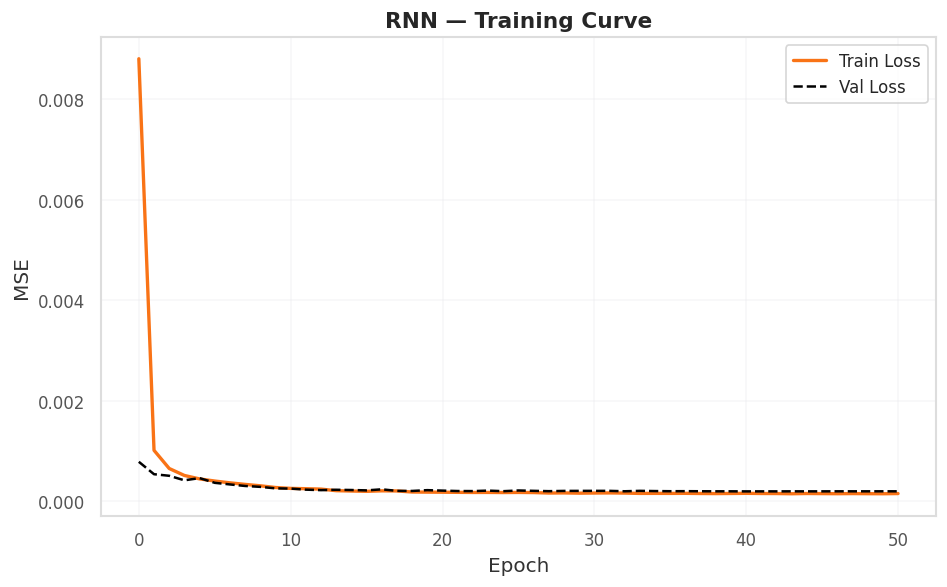

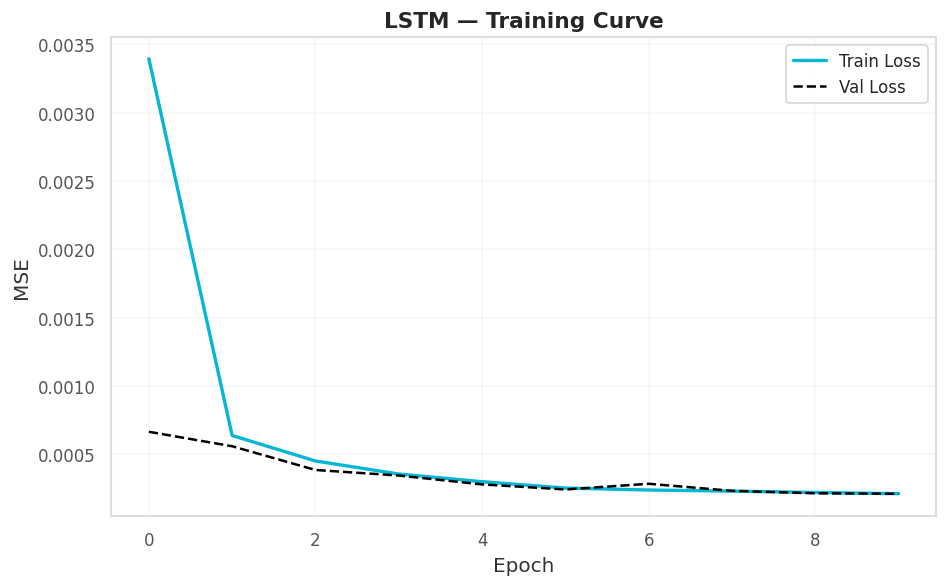

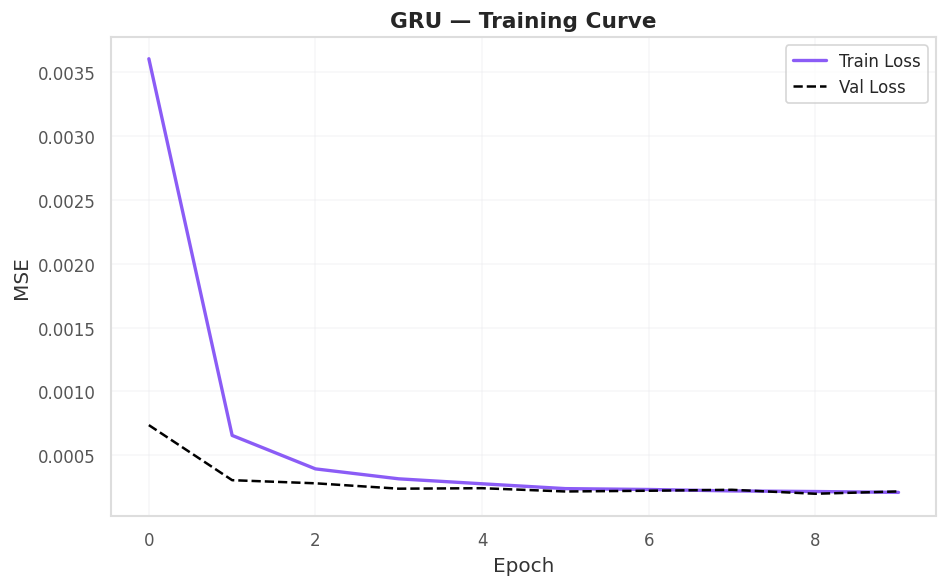

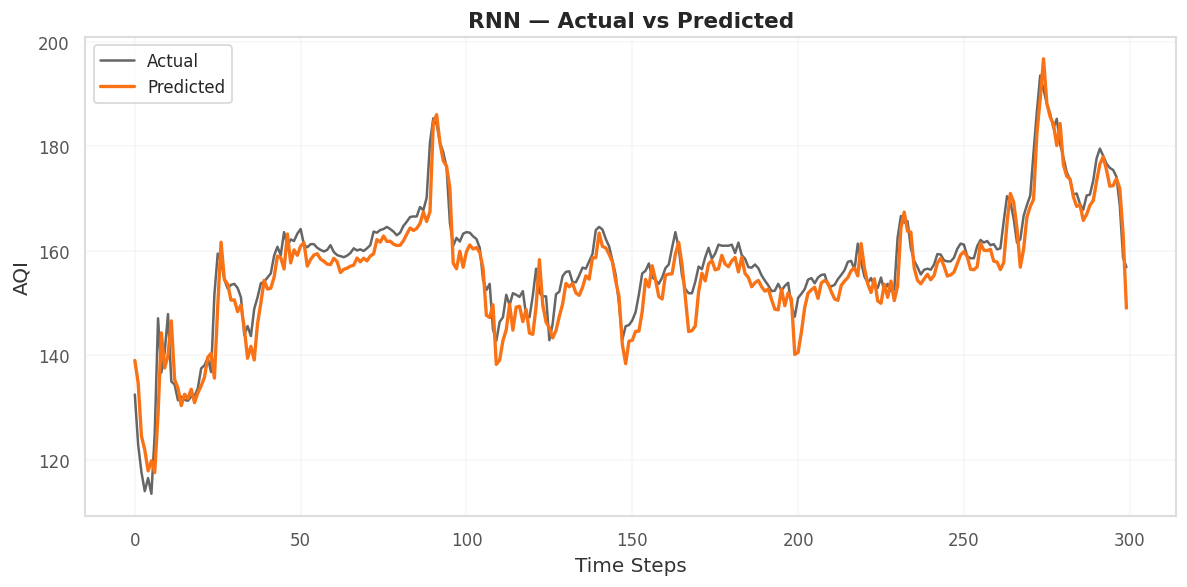

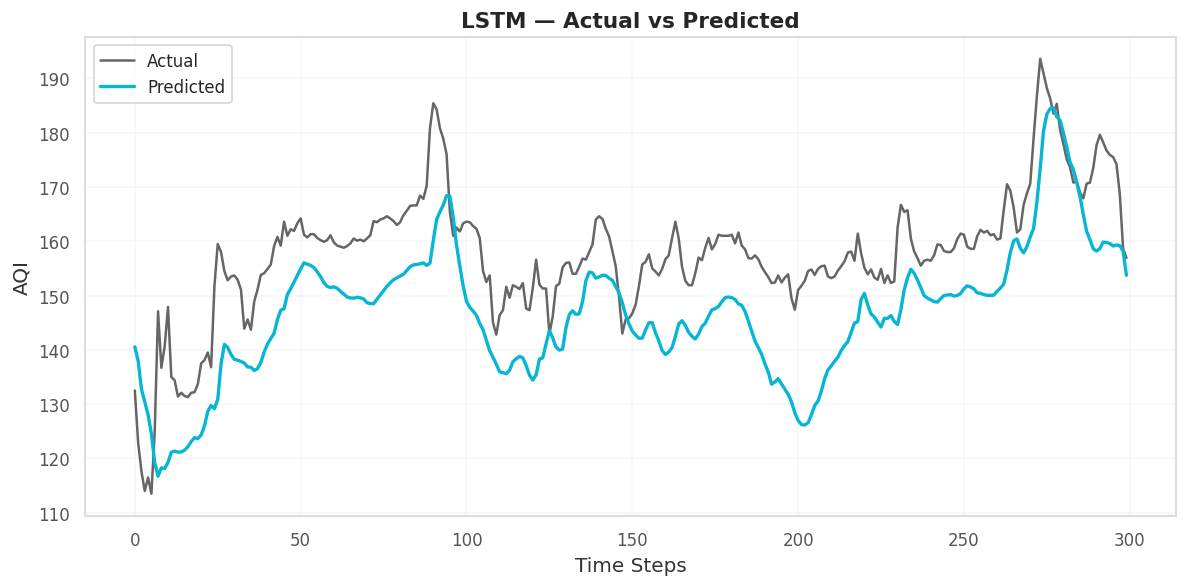

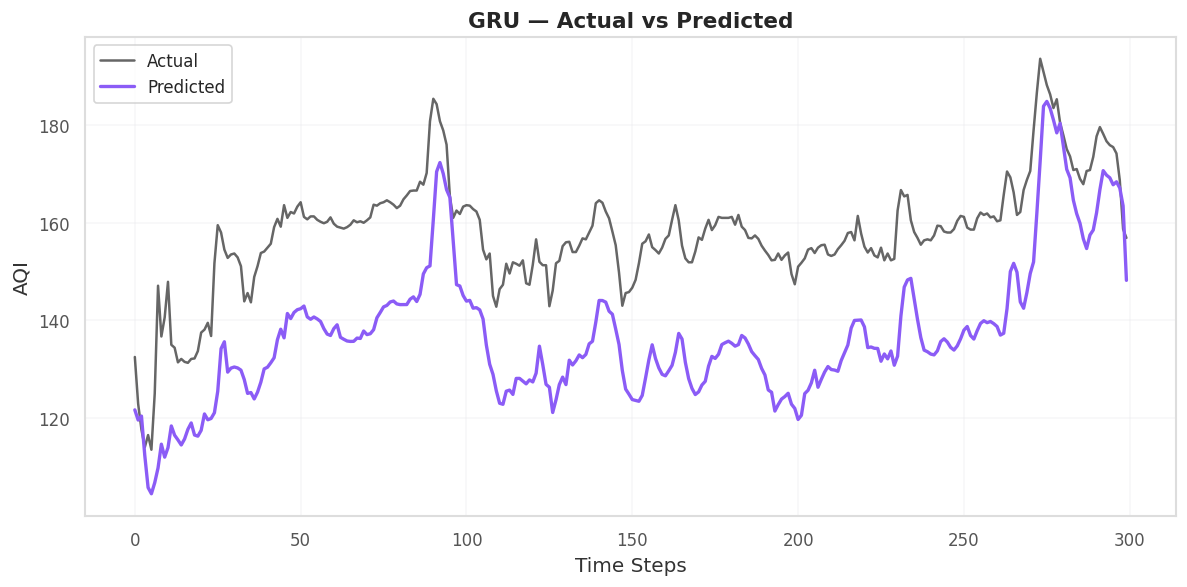


✅ All plots saved in ./plots/


In [46]:
import os
import matplotlib.pyplot as plt
import numpy as np

# ── Ensure plots directory exists ─────────────────
SAVE_DIR = "./plots"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Data ─────────────────────────────────────────
_EXP_KEY   = "rnn_lstm_gru"
_plot_data = EXPERIMENT_REGISTRY[_EXP_KEY]["results"]
_plot_hist = EXPERIMENT_REGISTRY[_EXP_KEY]["histories"]

COLORS = {"RNN": "#f97316", "LSTM": "#06b6d4", "GRU": "#8b5cf6"}
N_SHOW = 300
SAVE_PREFIX = "aqi_plot"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#dddddd",
    "axes.labelcolor": "#333333",
    "xtick.color": "#555555",
    "ytick.color": "#555555",
    "grid.color": "#e5e7eb",
    "font.size": 10
})

# ============================================================
# 1. LOSS CURVES
# ============================================================
for kind in ["RNN", "LSTM", "GRU"]:
    plt.figure(figsize=(8, 5))
    h = _plot_hist[kind]

    plt.plot(h["loss"], label="Train Loss", color=COLORS[kind], lw=2)
    plt.plot(h["val_loss"], label="Val Loss", color="black", ls="--", lw=1.5)

    plt.title(f"{kind} — Training Curve", fontsize=13, weight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{SAVE_PREFIX}_{kind.lower()}_loss.png", dpi=150)
    plt.show()

# ============================================================
# 2. ACTUAL vs PREDICTED
# ============================================================
for kind in ["RNN", "LSTM", "GRU"]:
    plt.figure(figsize=(10, 5))

    yt = _plot_data[kind]["y_true"][:N_SHOW]
    yp = _plot_data[kind]["y_pred"][:N_SHOW]

    plt.plot(yt, label="Actual", color="black", alpha=0.6)
    plt.plot(yp, label="Predicted", color=COLORS[kind], lw=2)

    plt.title(f"{kind} — Actual vs Predicted", fontsize=13, weight="bold")
    plt.xlabel("Time Steps")
    plt.ylabel("AQI")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{SAVE_PREFIX}_{kind.lower()}_timeseries.png", dpi=150)
    plt.show()

print(f"\n✅ All plots saved in {SAVE_DIR}/")

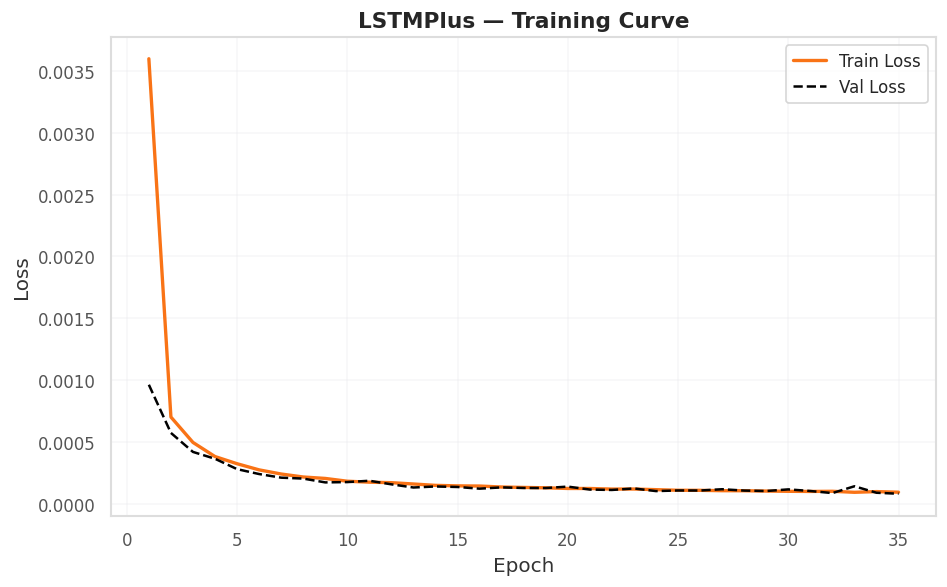

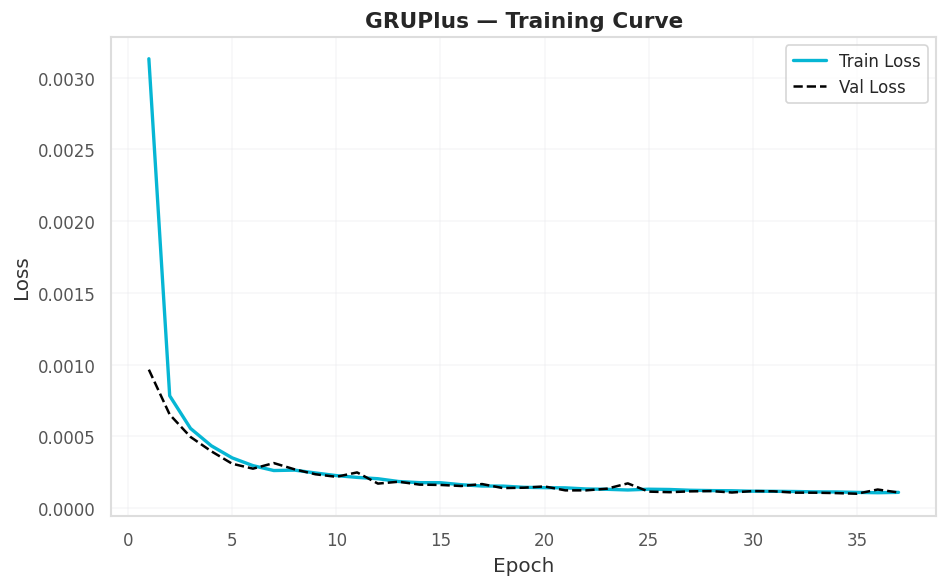

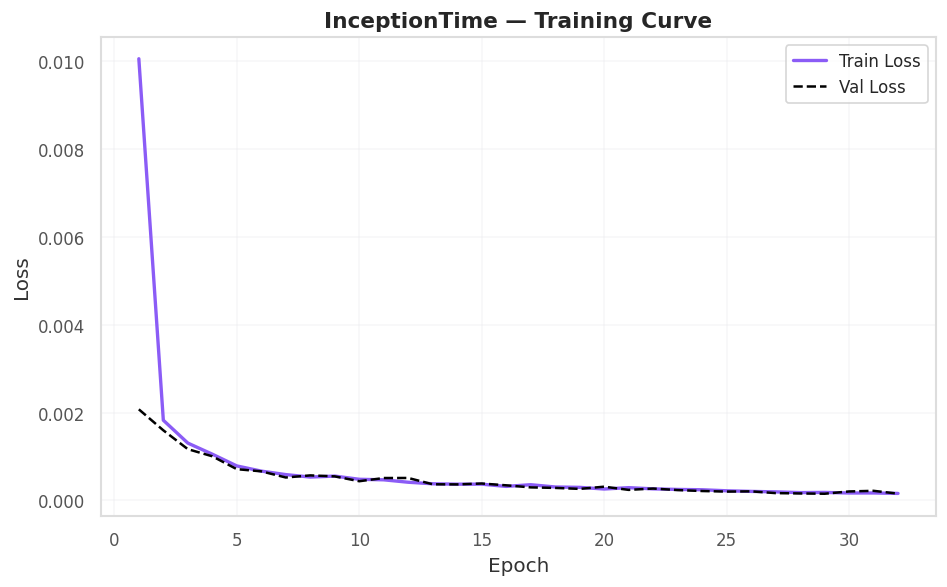

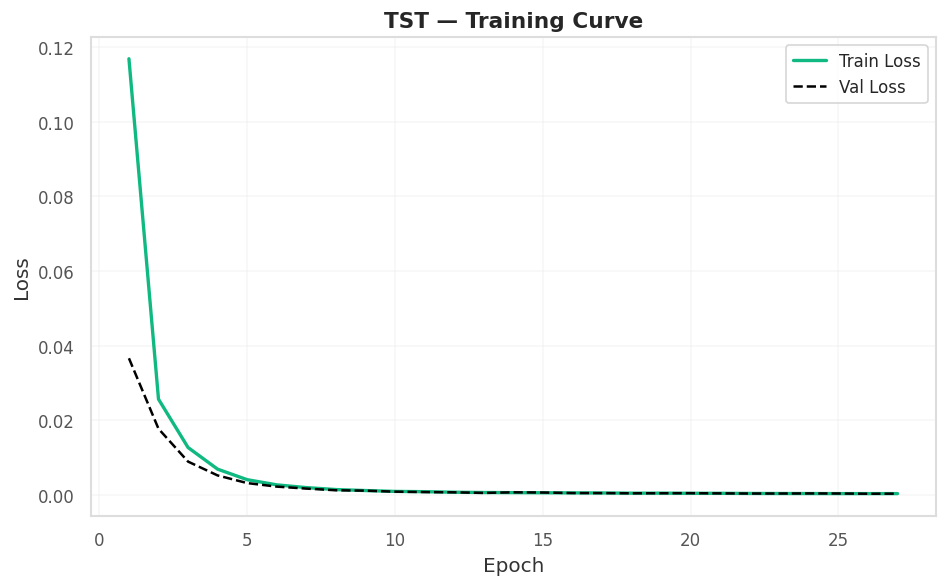

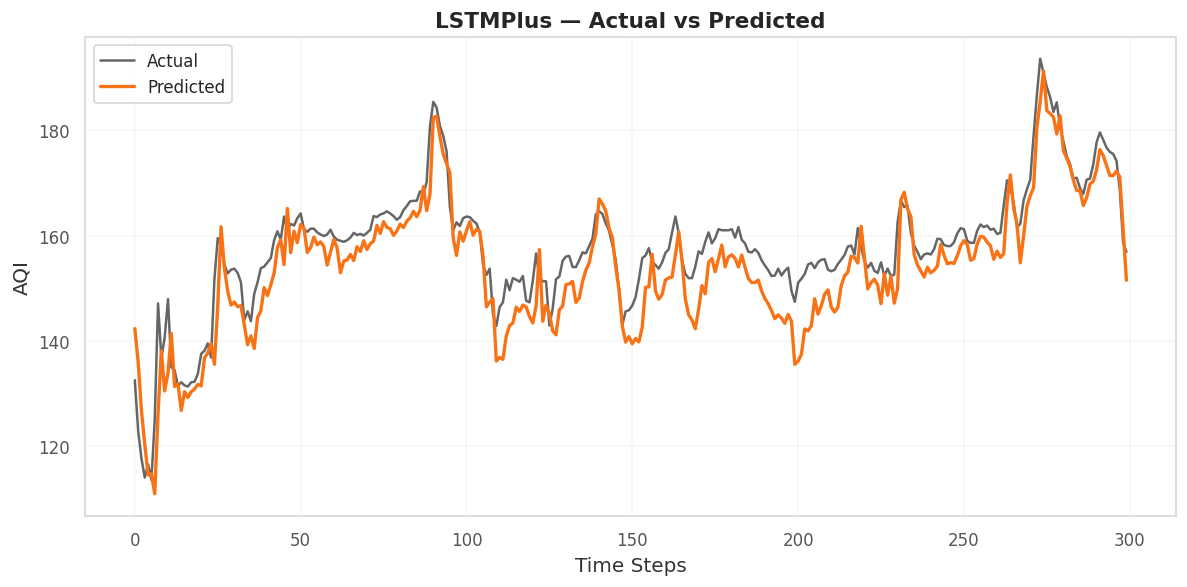

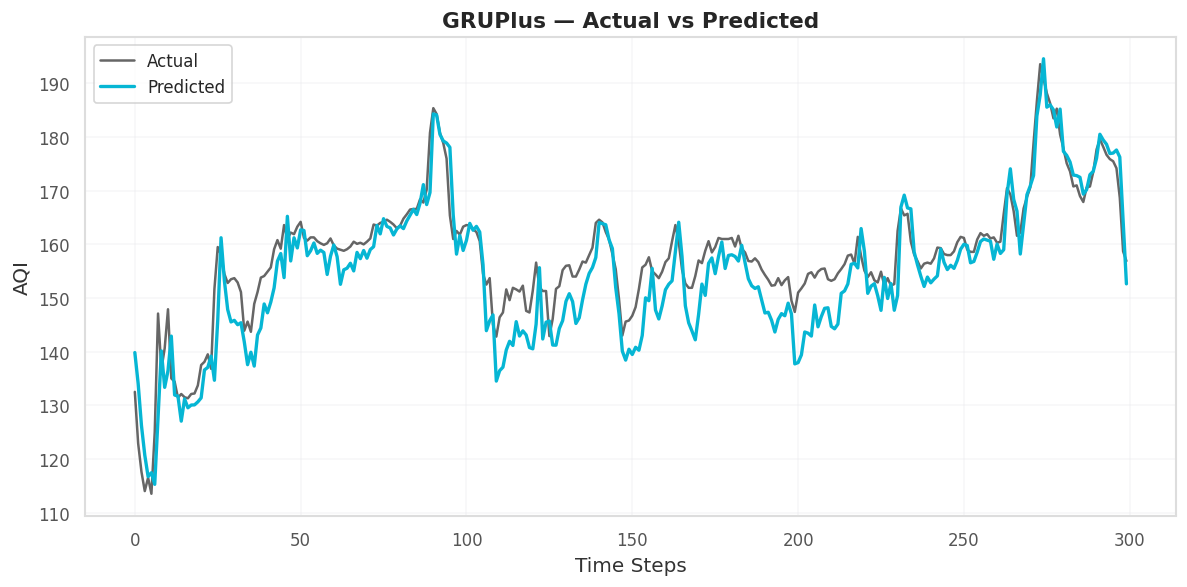

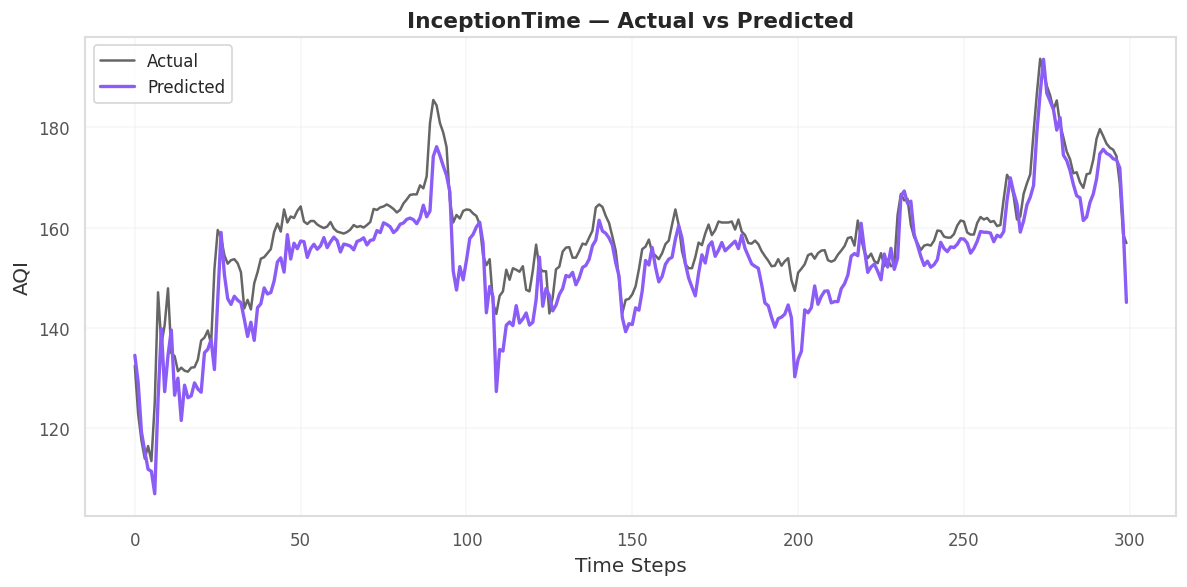

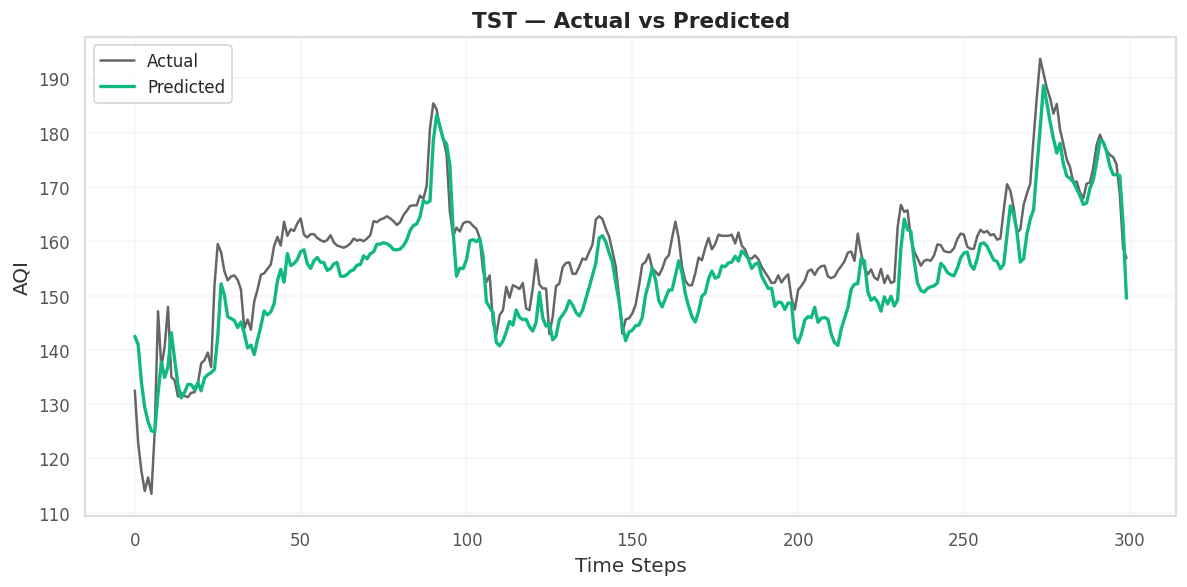


✅ All tsai model plots saved in ./plots/


In [47]:
import os
import matplotlib.pyplot as plt
import numpy as np

# ── Ensure plots directory exists ─────────────────
SAVE_DIR = "./plots"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Data ─────────────────────────────────────────
_EXP_KEY   = "tsai_models"
_plot_data = EXPERIMENT_REGISTRY[_EXP_KEY]["results"]
_plot_hist = EXPERIMENT_REGISTRY[_EXP_KEY]["histories"]

COLORS = {
    "LSTMPlus":      "#f97316",
    "GRUPlus":       "#06b6d4",
    "InceptionTime": "#8b5cf6",
    "TST":           "#10b981",
}

N_SHOW      = 300
SAVE_PREFIX = "aqi_tsai"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#dddddd",
    "axes.labelcolor": "#333333",
    "xtick.color": "#555555",
    "ytick.color": "#555555",
    "grid.color": "#e5e7eb",
    "font.size": 10
})

_names = list(_plot_data.keys())

# ============================================================
# 1. LOSS CURVES
# ============================================================
for name in _names:
    plt.figure(figsize=(8, 5))

    h = _plot_hist[name]
    train_loss = np.array(h["train"]).flatten()
    valid_loss = np.array(h["valid"]).flatten()
    epochs = range(1, len(train_loss) + 1)

    plt.plot(epochs, train_loss, label="Train Loss", color=COLORS[name], lw=2)
    plt.plot(epochs, valid_loss, label="Val Loss", color="black", ls="--", lw=1.5)

    plt.title(f"{name} — Training Curve", fontsize=13, weight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{SAVE_PREFIX}_{name.lower()}_loss.png", dpi=150)
    plt.show()

# ============================================================
# 2. ACTUAL vs PREDICTED
# ============================================================
for name in _names:
    plt.figure(figsize=(10, 5))

    yt = _plot_data[name]["y_true"][:N_SHOW]
    yp = _plot_data[name]["y_pred"][:N_SHOW]

    plt.plot(yt, label="Actual", color="black", alpha=0.6)
    plt.plot(yp, label="Predicted", color=COLORS[name], lw=2)

    plt.title(f"{name} — Actual vs Predicted", fontsize=13, weight="bold")
    plt.xlabel("Time Steps")
    plt.ylabel("AQI")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{SAVE_PREFIX}_{name.lower()}_timeseries.png", dpi=150)
    plt.show()

print(f"\n✅ All tsai model plots saved in {SAVE_DIR}/")

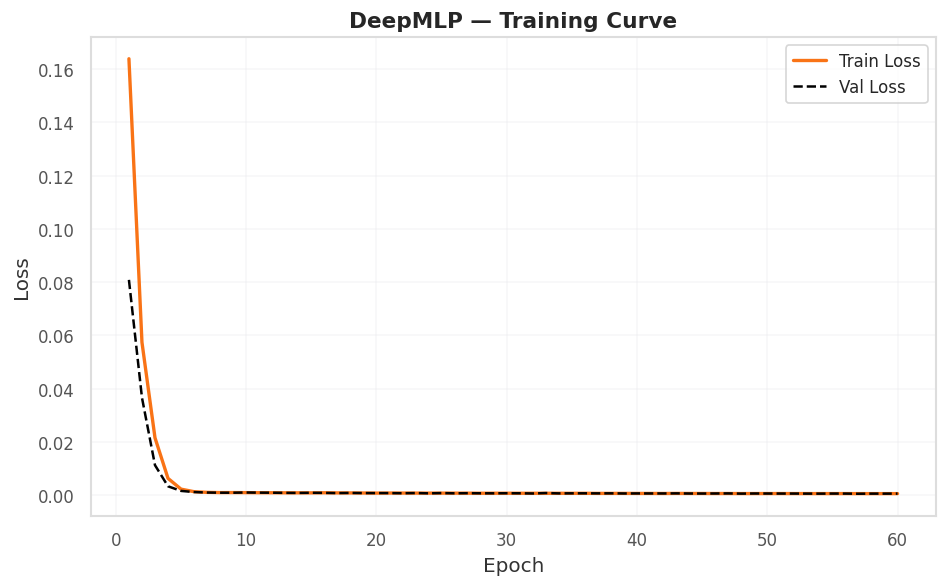

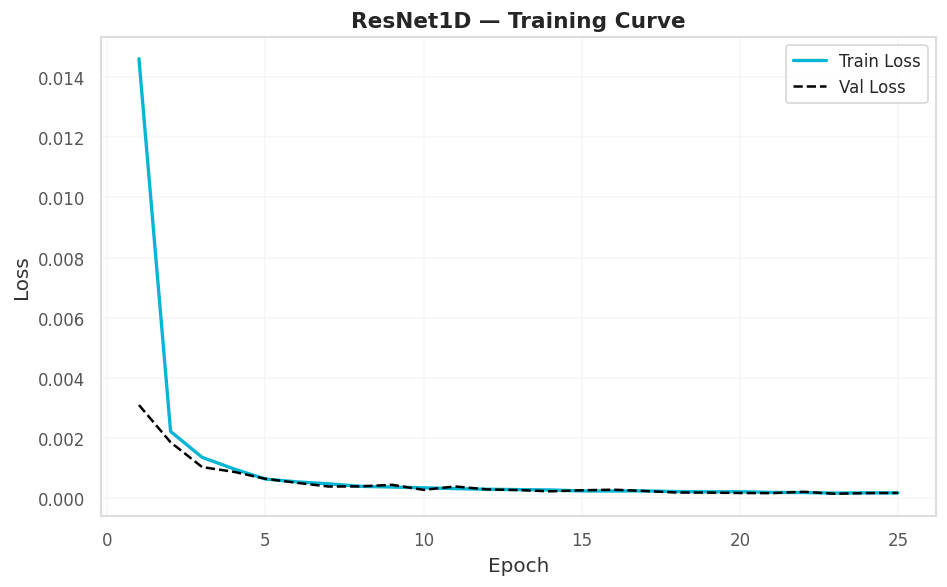

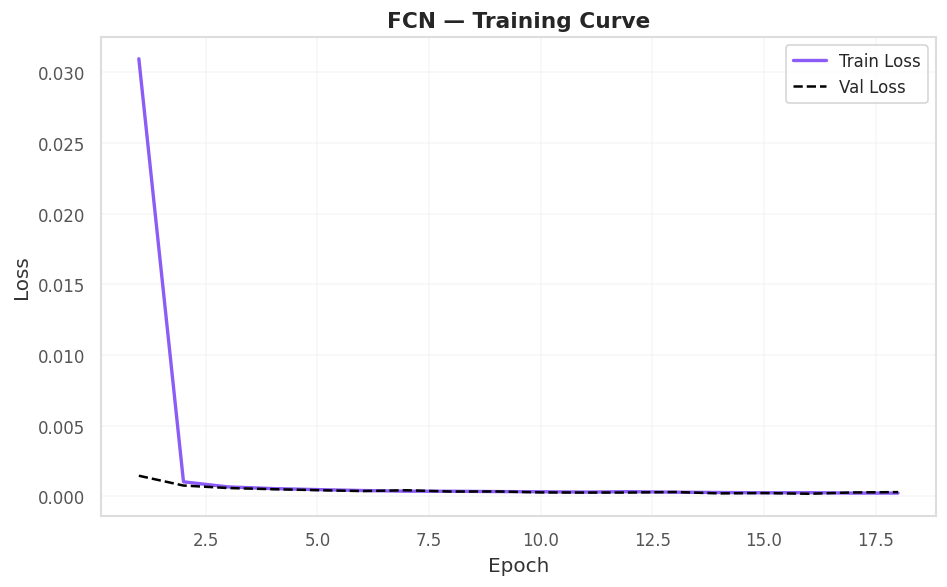

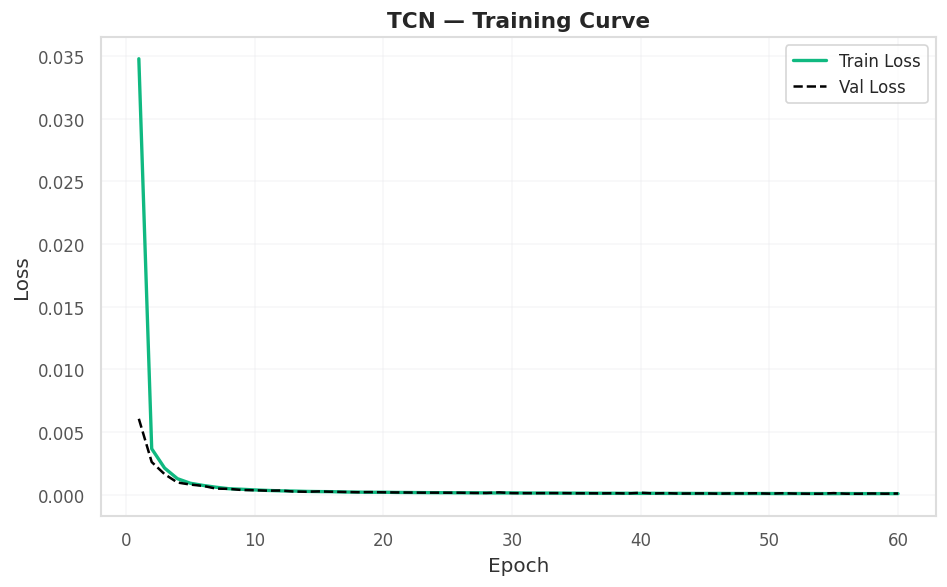

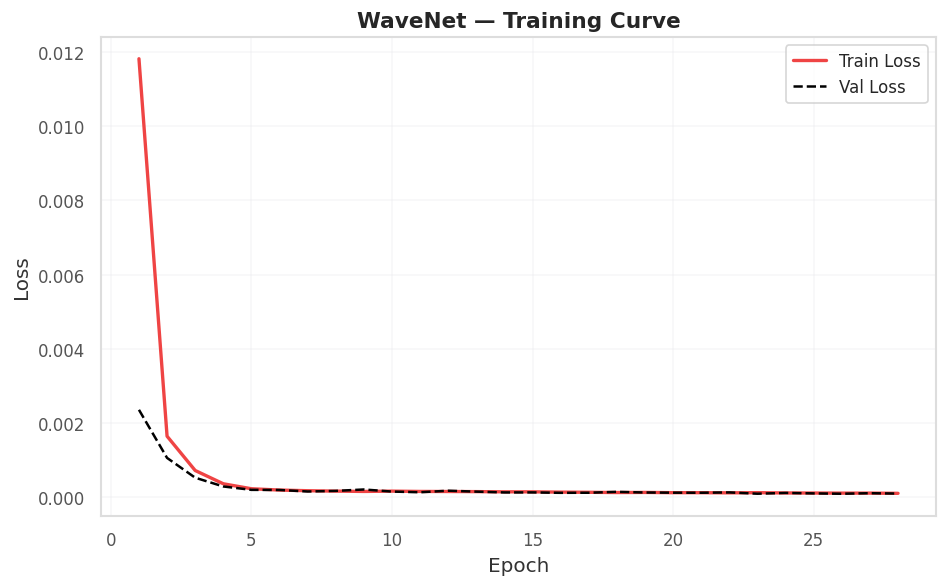

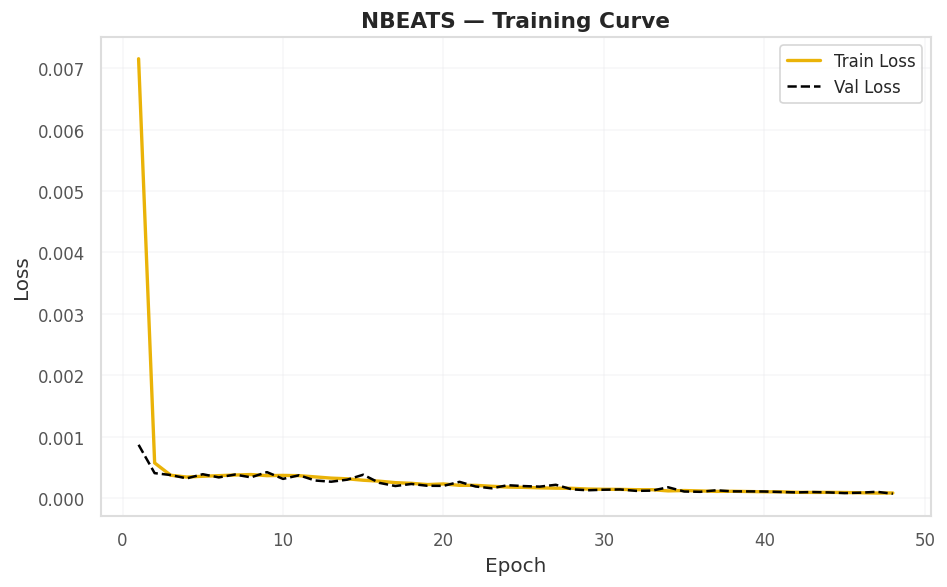

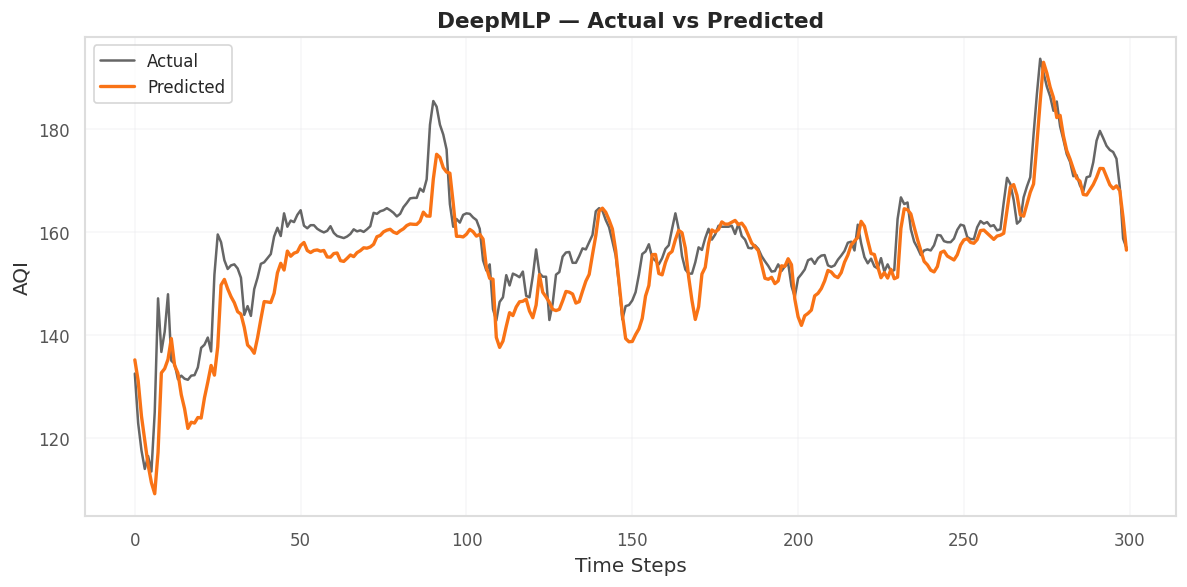

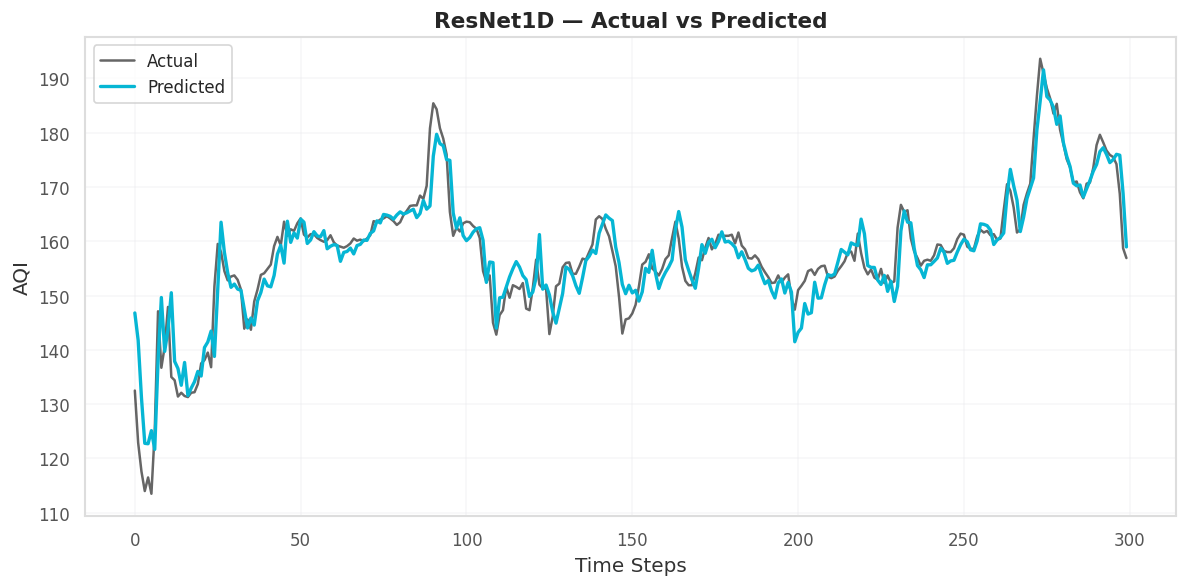

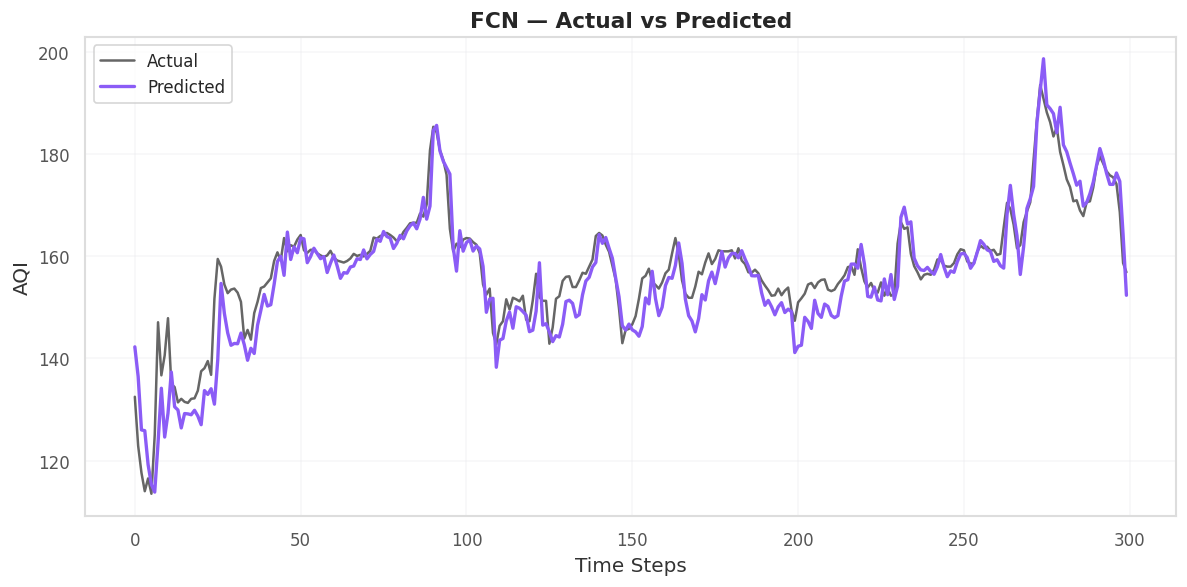

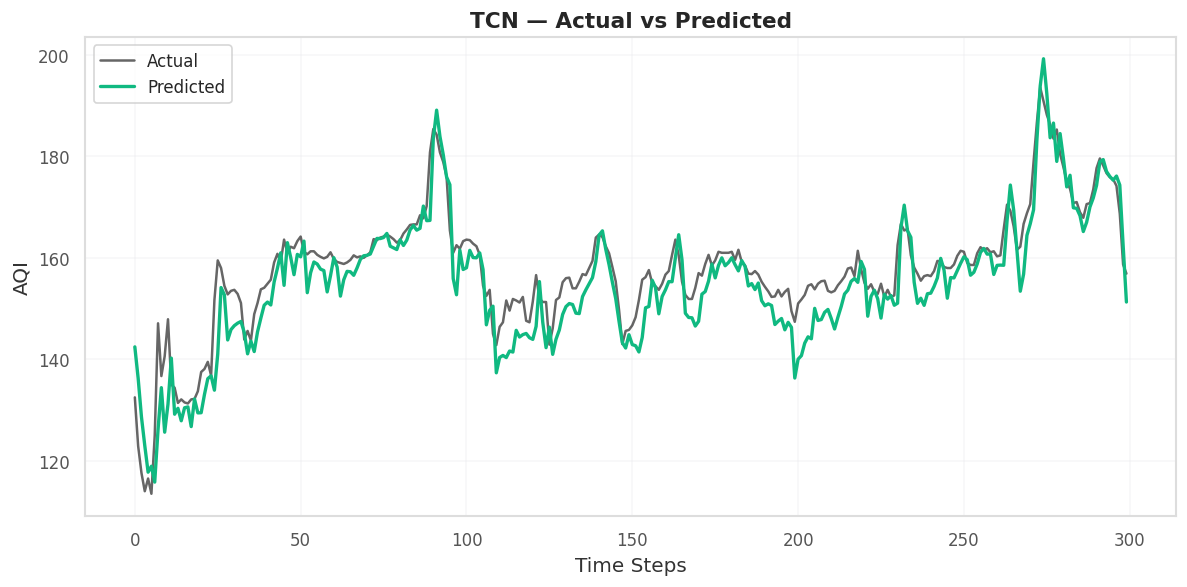

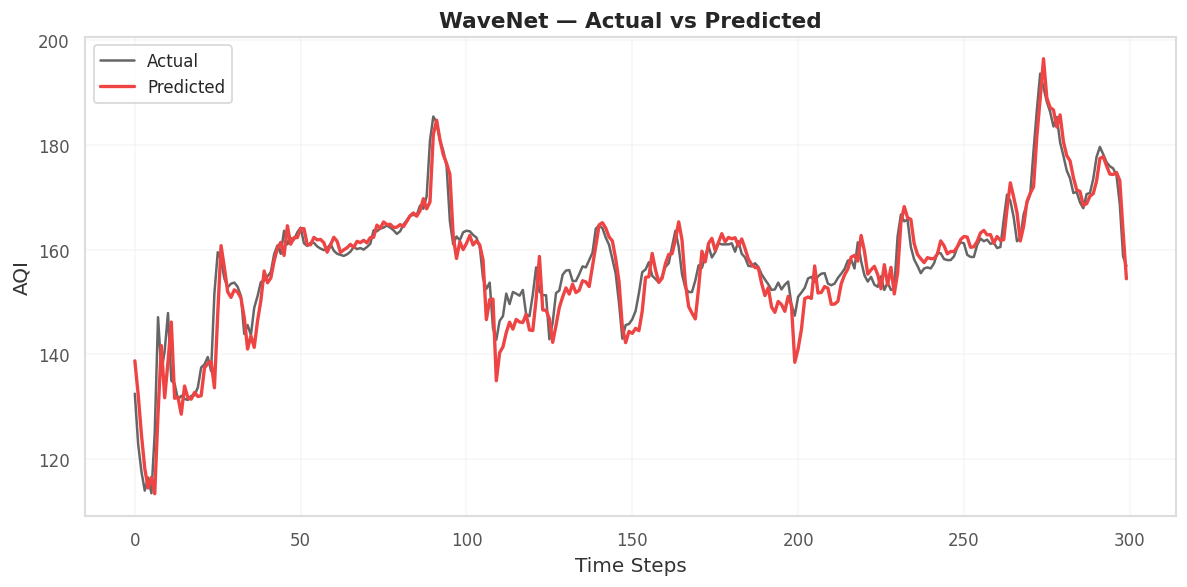

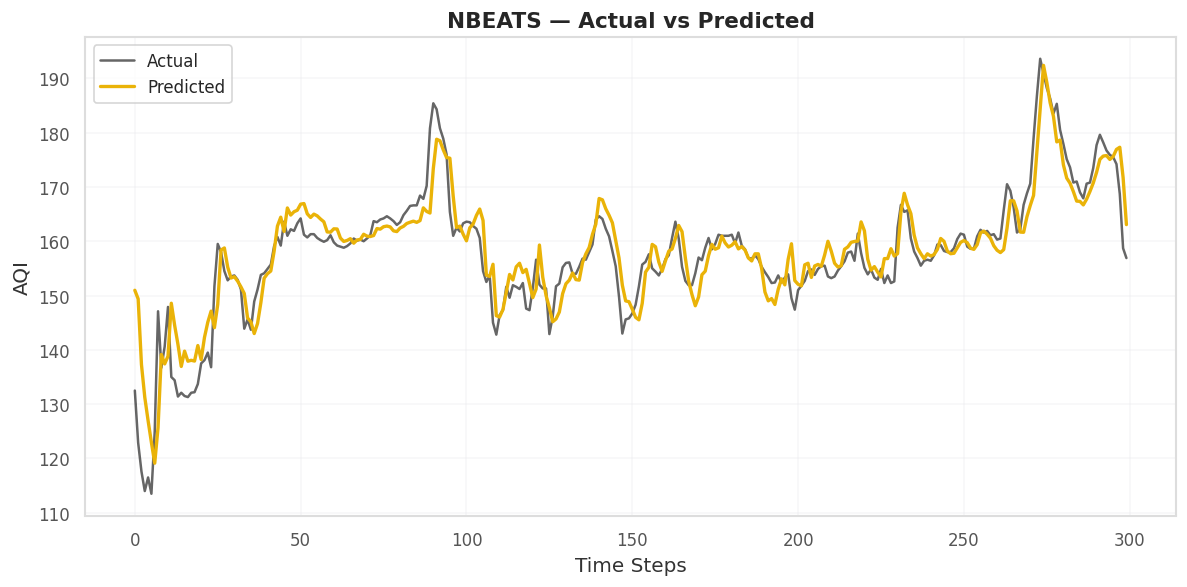


✅ All classic NN plots saved in ./plots/


In [48]:
import os
import matplotlib.pyplot as plt
import numpy as np

# ── Ensure plots directory exists ─────────────────
SAVE_DIR = "./plots"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Data ─────────────────────────────────────────
_EXP_KEY   = "classic_nn"
_plot_data = EXPERIMENT_REGISTRY[_EXP_KEY]["results"]
_plot_hist = EXPERIMENT_REGISTRY[_EXP_KEY]["histories"]

COLORS = {
    "DeepMLP":  "#f97316",
    "ResNet1D": "#06b6d4",
    "FCN":      "#8b5cf6",
    "TCN":      "#10b981",
    "WaveNet":  "#ef4444",
    "NBEATS":   "#eab308",
}

N_SHOW      = 300
SAVE_PREFIX = "aqi_classic_nn"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#dddddd",
    "axes.labelcolor": "#333333",
    "xtick.color": "#555555",
    "ytick.color": "#555555",
    "grid.color": "#e5e7eb",
    "font.size": 10
})

_names = list(_plot_data.keys())

# ============================================================
# 1. LOSS CURVES
# ============================================================
for name in _names:
    plt.figure(figsize=(8, 5))

    h = _plot_hist[name]
    train_loss = np.array(h["train"]).flatten()
    valid_loss = np.array(h["valid"]).flatten()
    epochs = range(1, len(train_loss) + 1)

    plt.plot(epochs, train_loss, label="Train Loss", color=COLORS[name], lw=2)
    plt.plot(epochs, valid_loss, label="Val Loss", color="black", ls="--", lw=1.5)

    plt.title(f"{name} — Training Curve", fontsize=13, weight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{SAVE_PREFIX}_{name.lower()}_loss.png", dpi=150)
    plt.show()

# ============================================================
# 2. ACTUAL vs PREDICTED
# ============================================================
for name in _names:
    plt.figure(figsize=(10, 5))

    yt = _plot_data[name]["y_true"][:N_SHOW]
    yp = _plot_data[name]["y_pred"][:N_SHOW]

    plt.plot(yt, label="Actual", color="black", alpha=0.6)
    plt.plot(yp, label="Predicted", color=COLORS[name], lw=2)

    plt.title(f"{name} — Actual vs Predicted", fontsize=13, weight="bold")
    plt.xlabel("Time Steps")
    plt.ylabel("AQI")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{SAVE_PREFIX}_{name.lower()}_timeseries.png", dpi=150)
    plt.show()

print(f"\n✅ All classic NN plots saved in {SAVE_DIR}/")

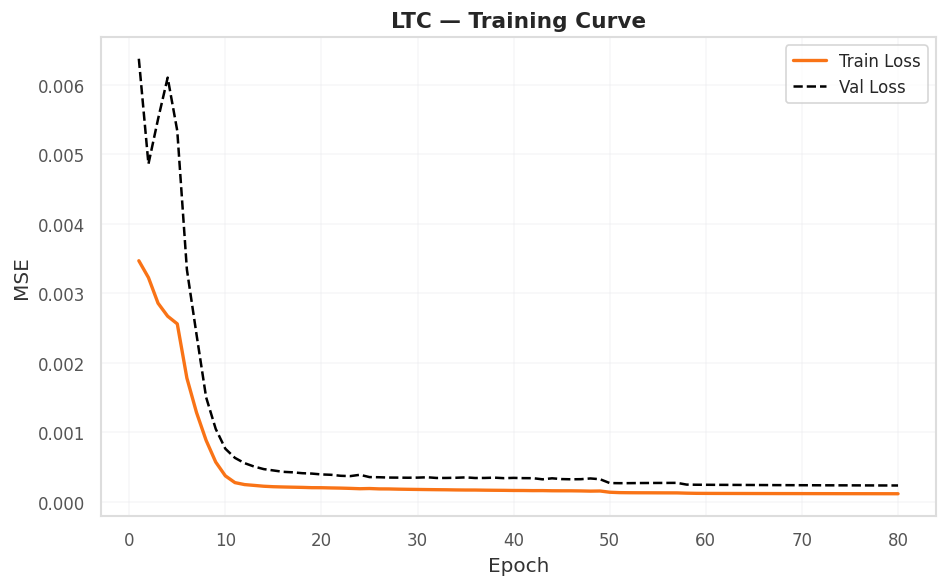

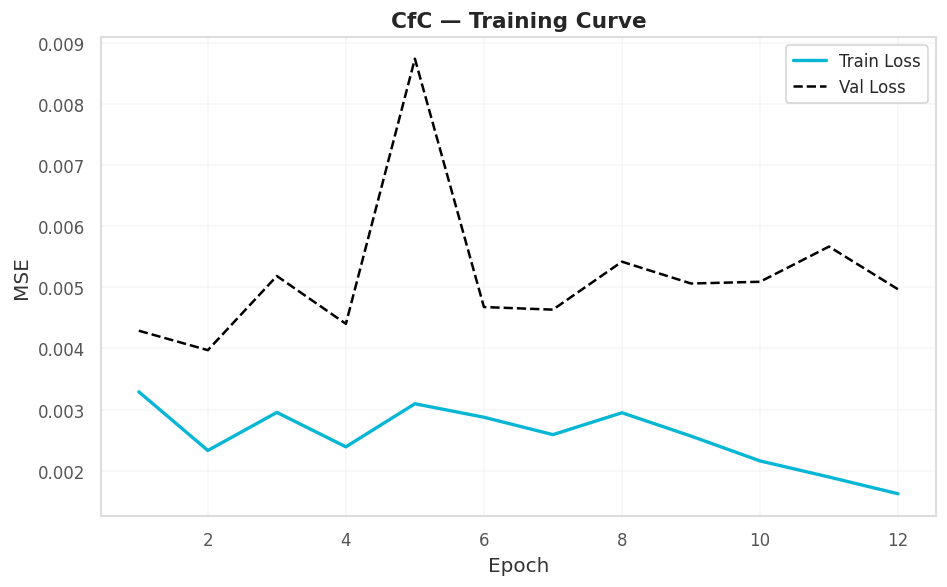

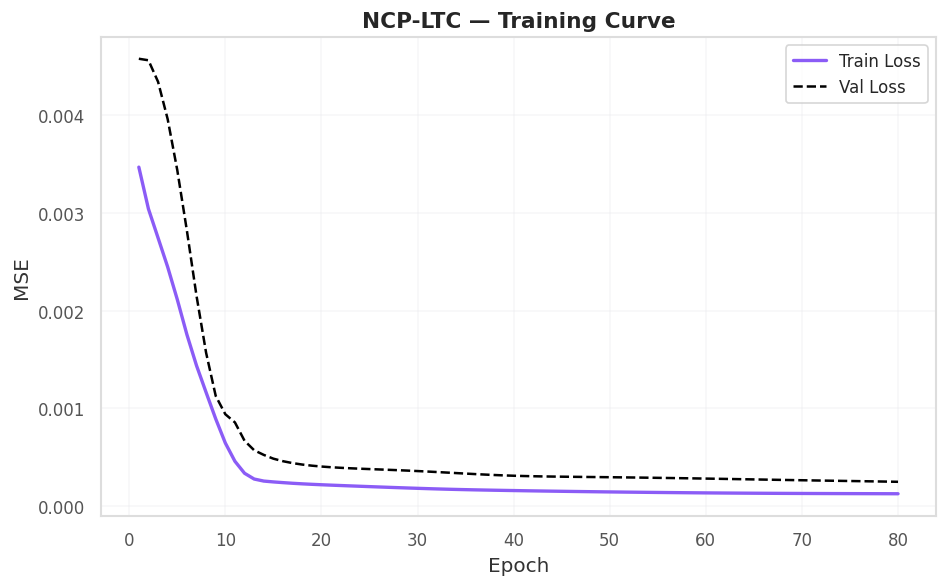

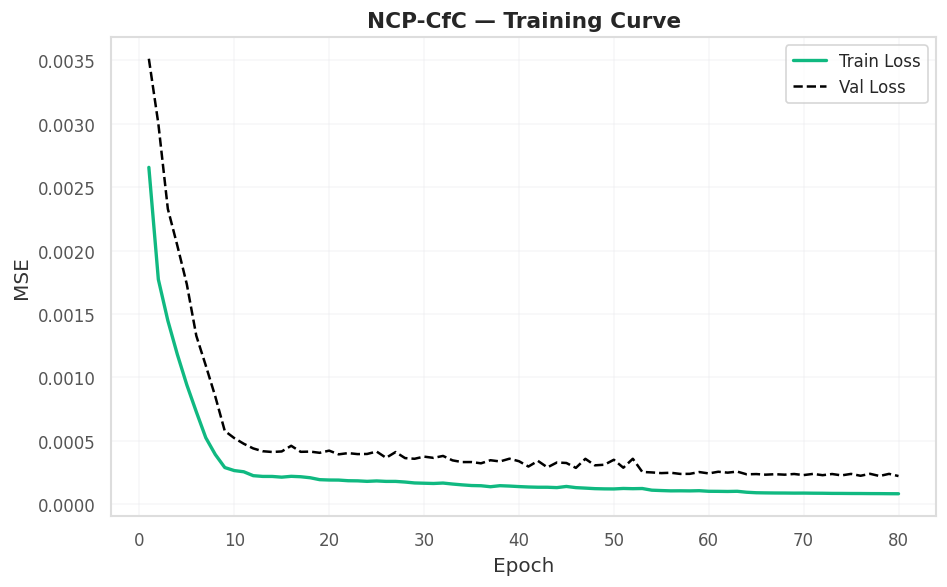

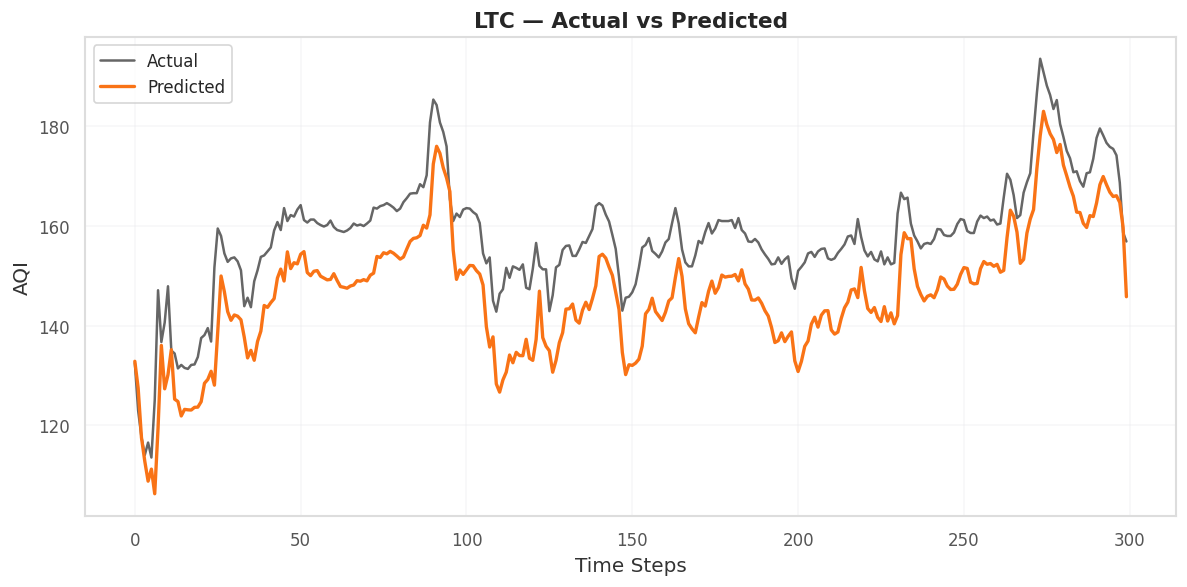

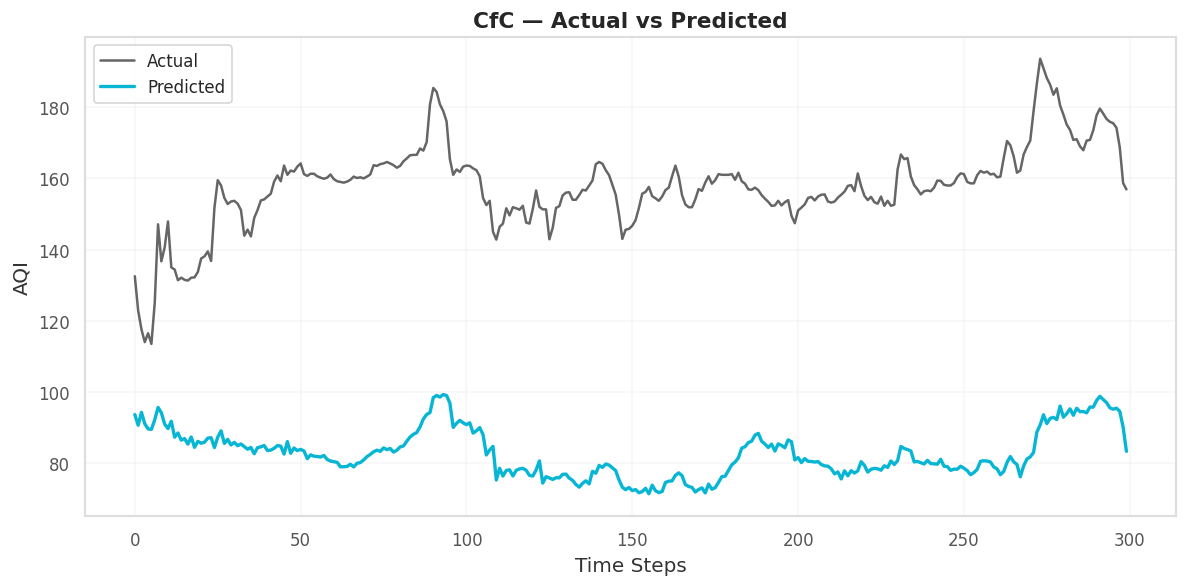

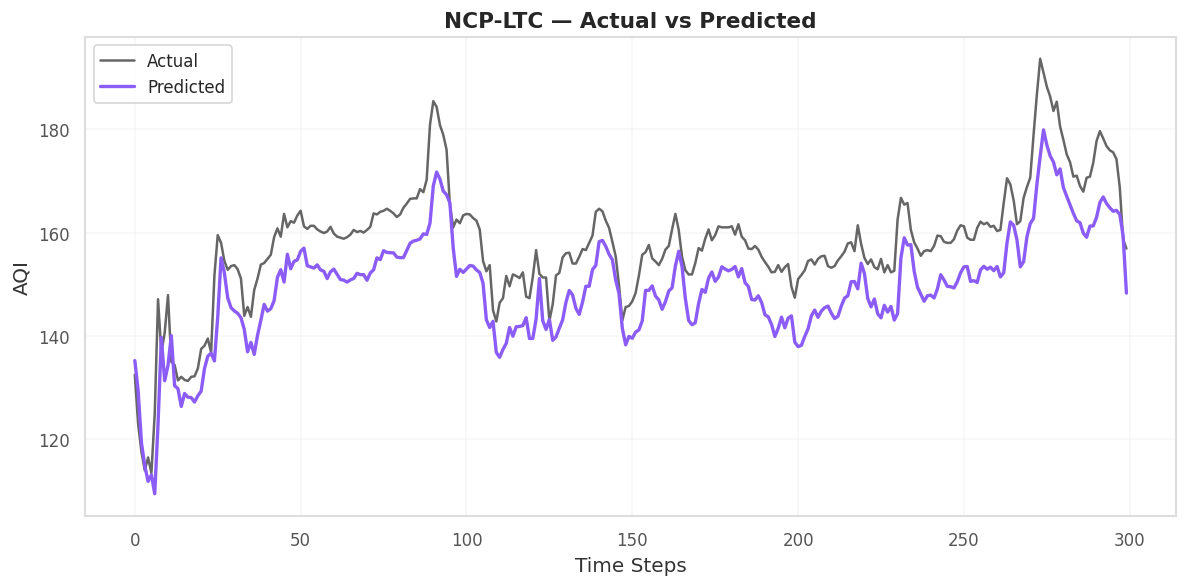

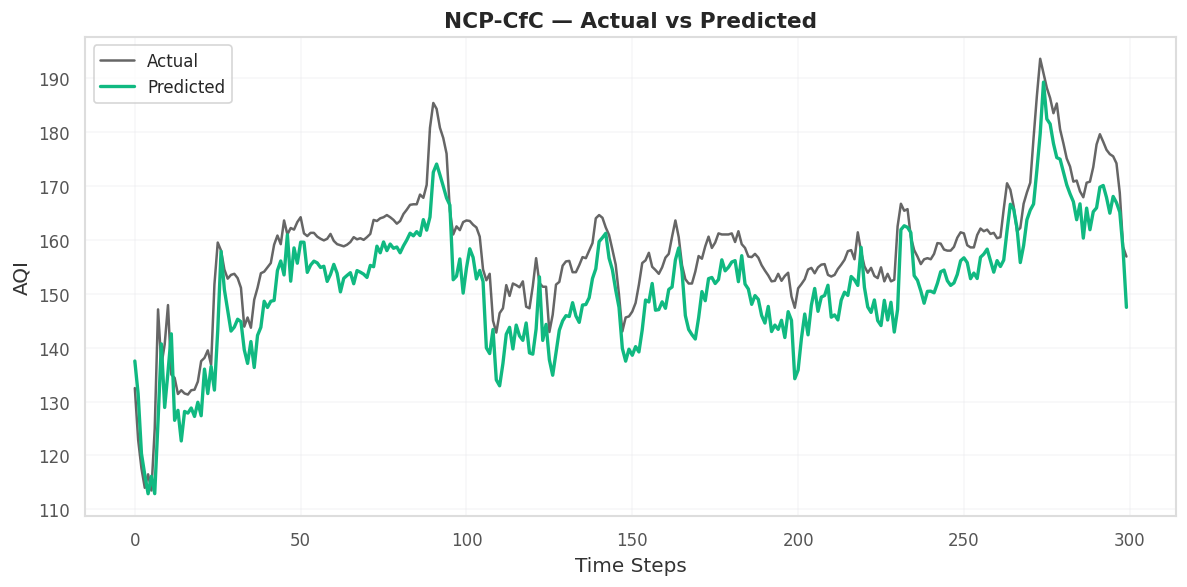


✅ All liquid NN plots saved in ./plots/


In [49]:
import os
import matplotlib.pyplot as plt
import numpy as np

# ── Ensure plots directory exists ─────────────────
SAVE_DIR = "./plots"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Data ─────────────────────────────────────────
_EXP_KEY   = "liquid_nn"
_plot_data = EXPERIMENT_REGISTRY[_EXP_KEY]["results"]
_plot_hist = EXPERIMENT_REGISTRY[_EXP_KEY]["histories"]

COLORS = {
    "LTC":     "#f97316",
    "CfC":     "#06b6d4",
    "NCP-LTC": "#8b5cf6",
    "NCP-CfC": "#10b981",
}

N_SHOW      = 300
SAVE_PREFIX = "aqi_liquid_nn"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#dddddd",
    "axes.labelcolor": "#333333",
    "xtick.color": "#555555",
    "ytick.color": "#555555",
    "grid.color": "#e5e7eb",
    "font.size": 10
})

_names = list(_plot_data.keys())

# ============================================================
# 1. LOSS CURVES
# ============================================================
for name in _names:
    plt.figure(figsize=(8, 5))

    h = _plot_hist[name]
    train_loss = np.array(h["train"]).flatten()
    val_loss   = np.array(h["val"]).flatten()
    epochs = range(1, len(train_loss) + 1)

    plt.plot(epochs, train_loss, label="Train Loss", color=COLORS[name], lw=2)
    plt.plot(epochs, val_loss,   label="Val Loss",   color="black", ls="--", lw=1.5)

    plt.title(f"{name} — Training Curve", fontsize=13, weight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{SAVE_PREFIX}_{name.lower()}_loss.png", dpi=150)
    plt.show()

# ============================================================
# 2. ACTUAL vs PREDICTED
# ============================================================
for name in _names:
    plt.figure(figsize=(10, 5))

    yt = _plot_data[name]["y_true"][:N_SHOW]
    yp = _plot_data[name]["y_pred"][:N_SHOW]

    plt.plot(yt, label="Actual", color="black", alpha=0.6)
    plt.plot(yp, label="Predicted", color=COLORS[name], lw=2)

    plt.title(f"{name} — Actual vs Predicted", fontsize=13, weight="bold")
    plt.xlabel("Time Steps")
    plt.ylabel("AQI")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/{SAVE_PREFIX}_{name.lower()}_timeseries.png", dpi=150)
    plt.show()

print(f"\n✅ All liquid NN plots saved in {SAVE_DIR}/")

✅ Models after exclusion: 15


/tmp/ipykernel_66874/1898926259.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(_names))


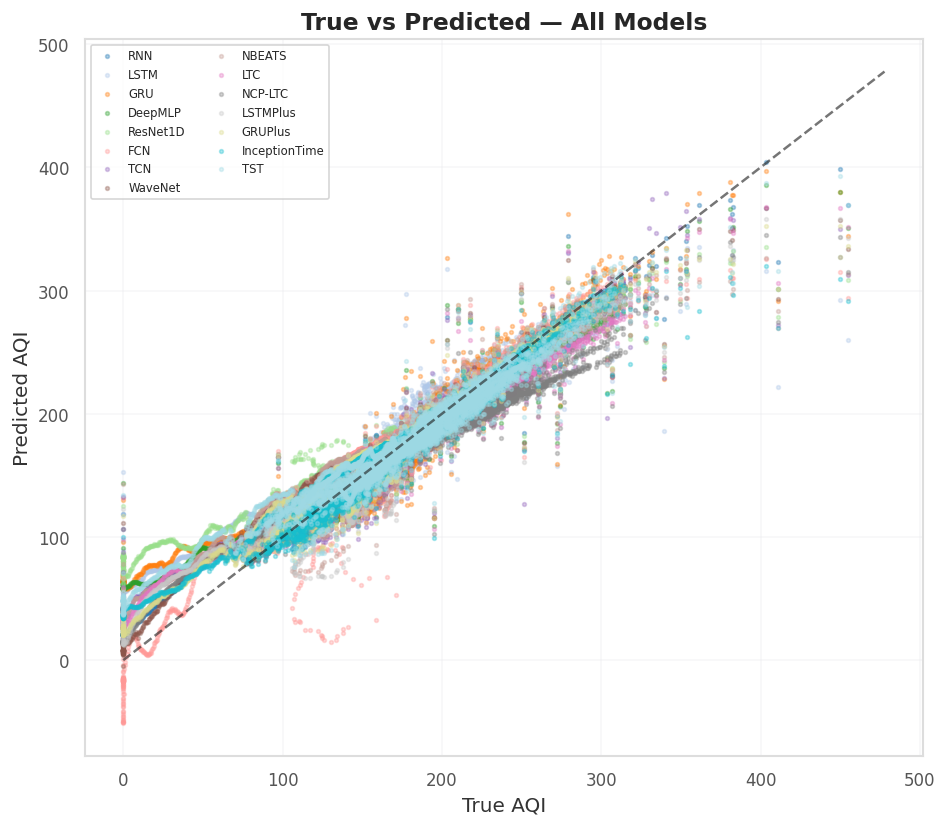

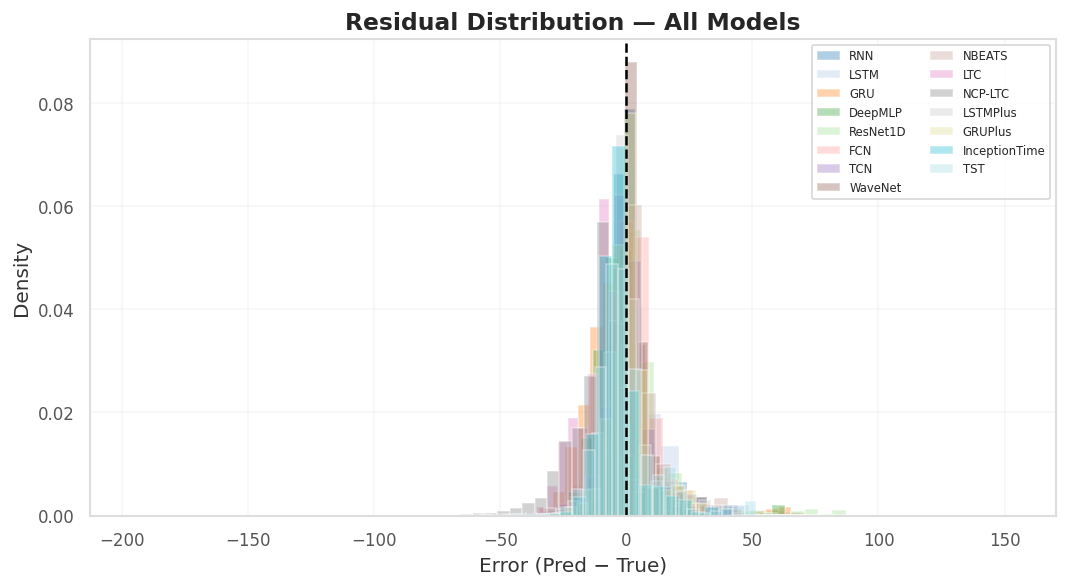

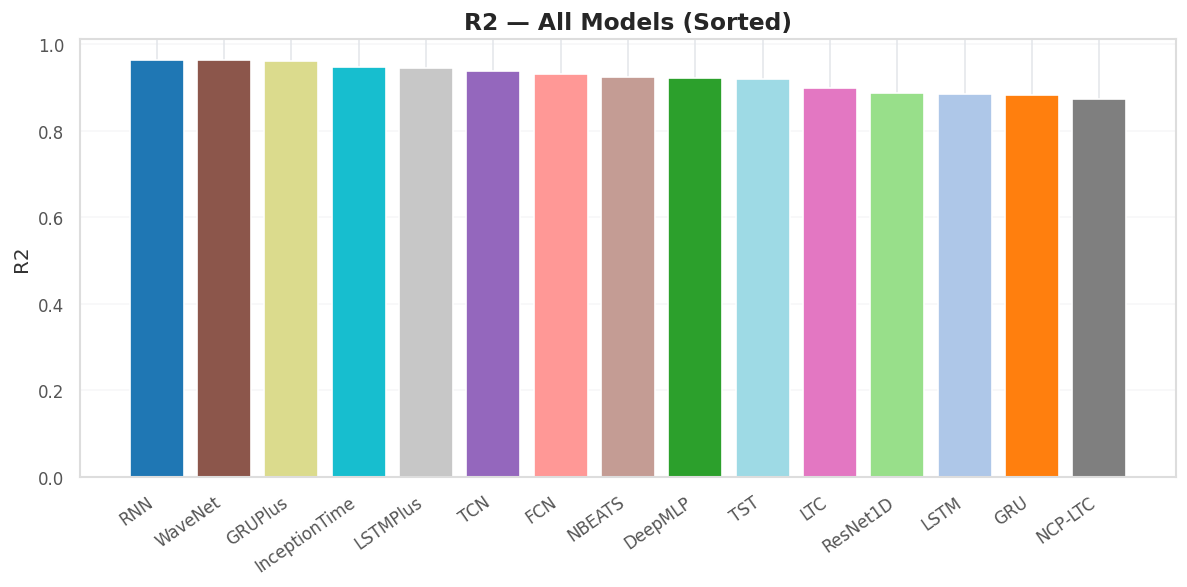

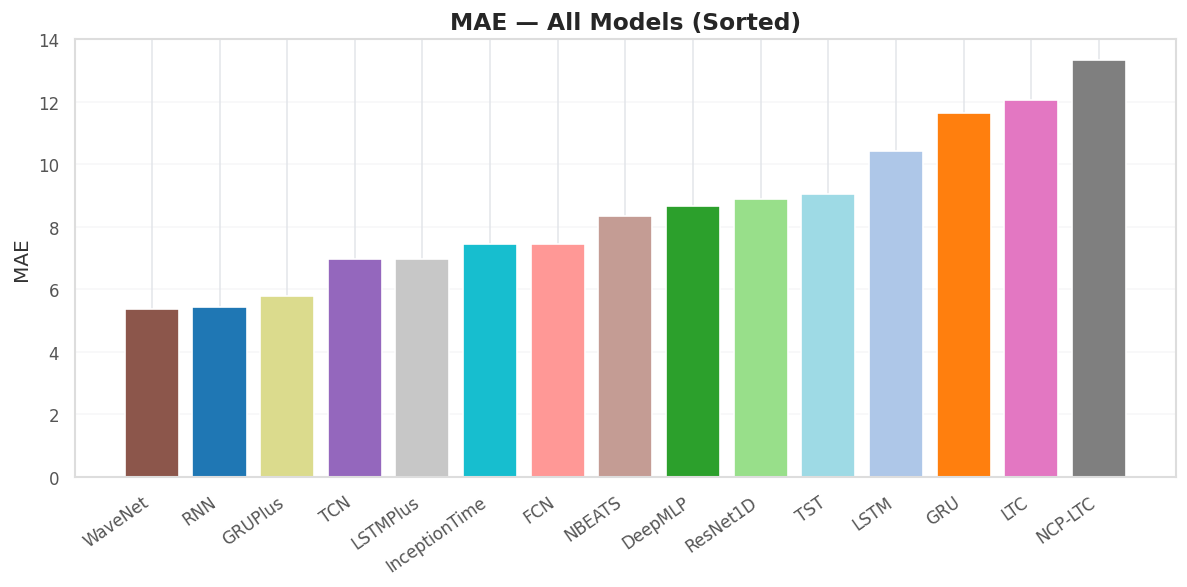

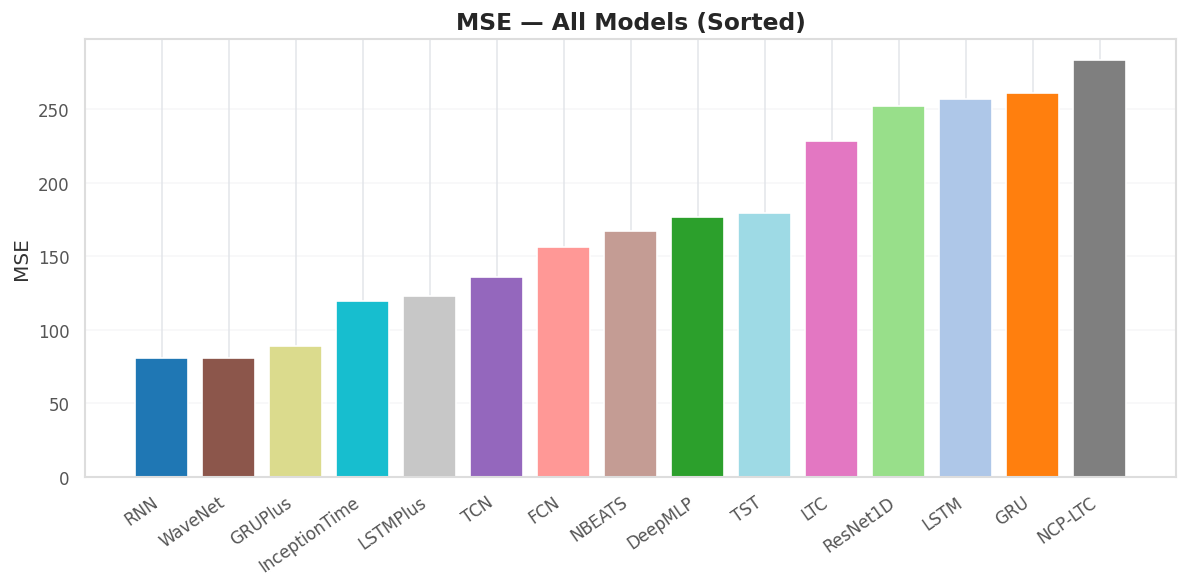


🔥 Done. Clean, colorful plots saved in ./plots/


In [50]:
import os
import matplotlib.pyplot as plt
import numpy as np

SAVE_DIR = "./plots"
os.makedirs(SAVE_DIR, exist_ok=True)

# ============================================================
# 🔥 COLLECT ALL MODELS (EXCLUDING CfC)
# ============================================================
EXCLUDE = {"CfC", "NCP-CfC"}

ALL_DATA = {}

for exp in ["rnn_lstm_gru", "classic_nn", "liquid_nn", "tsai_models"]:
    results = EXPERIMENT_REGISTRY[exp]["results"]
    for name, data in results.items():
        if name not in EXCLUDE:
            ALL_DATA[name] = data

_names = list(ALL_DATA.keys())
print(f"✅ Models after exclusion: {len(_names)}")

# 🎨 Color palette (auto for many models)
cmap = plt.cm.get_cmap("tab20", len(_names))
COLORS = {name: cmap(i) for i, name in enumerate(_names)}

# ============================================================
# 1. SCATTER (ALL MODELS)
# ============================================================
plt.figure(figsize=(8, 7))

for name in _names:
    yt = ALL_DATA[name]["y_true"]
    yp = ALL_DATA[name]["y_pred"]
    plt.scatter(yt, yp, s=5, alpha=0.35, label=name, color=COLORS[name])

lim = [0, max(ALL_DATA[n]["y_true"].max() for n in _names) * 1.05]
plt.plot(lim, lim, "k--", alpha=0.6)

plt.title("True vs Predicted — All Models", fontsize=14, weight="bold")
plt.xlabel("True AQI")
plt.ylabel("Predicted AQI")
plt.grid(alpha=0.3)

plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/all_models_scatter.png", dpi=150)
plt.show()

# ============================================================
# 2. RESIDUAL DISTRIBUTION
# ============================================================
plt.figure(figsize=(9, 5))

for name in _names:
    res = ALL_DATA[name]["y_pred"] - ALL_DATA[name]["y_true"]
    plt.hist(res, bins=50, alpha=0.35, density=True,
             label=name, color=COLORS[name])

plt.axvline(0, color="black", linestyle="--")

plt.title("Residual Distribution — All Models", fontsize=14, weight="bold")
plt.xlabel("Error (Pred − True)")
plt.ylabel("Density")
plt.grid(alpha=0.3)

plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/all_models_residuals.png", dpi=150)
plt.show()

# ============================================================
# 3. METRICS (SORTED — MUCH BETTER)
# ============================================================
metrics = ["R2", "MAE", "MSE"]

for metric in metrics:
    plt.figure(figsize=(10, 5))

    vals = np.array([ALL_DATA[k][metric] for k in _names])
    names = np.array(_names)

    # 🔥 Sort for readability
    if metric == "R2":
        order = np.argsort(-vals)  # higher is better
    else:
        order = np.argsort(vals)   # lower is better

    vals = vals[order]
    names = names[order]

    plt.bar(range(len(names)), vals,
            color=[COLORS[n] for n in names])

    plt.xticks(range(len(names)), names, rotation=35, ha="right")

    plt.title(f"{metric} — All Models (Sorted)", fontsize=14, weight="bold")
    plt.ylabel(metric)
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/all_models_{metric.lower()}.png", dpi=150)
    plt.show()

print(f"\n🔥 Done. Clean, colorful plots saved in {SAVE_DIR}/")